# Proyek Analisis Data: [E-Commerce Dataset]
- **Nama:** Ahcmad Ardhi Arridho
- **Email:** ardhigt17@gmail.com
- **ID Dicoding:** ardhi_arridho

## Menentukan Pertanyaan Bisnis


- Metode pembayaran apa yang paling sering digunakan oleh pelanggan?

- Bagaimana Tren Penjualan tiap bulannya dan evolusinya seiring waktu?

- Bagaimana hubungan antara harga produk, biaya pengiriman dan skor ulasan pelanggan?

-  Bagaimana mengelompokkan pelanggan berdasarkan perilaku pembelian mereka (Recency, Frequency, Monetary)?

- Provinsi mana yang memiliki total penjualan tertinggi dan terendah?


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import date2num


## Data Wrangling

### Gathering Data

In [2]:
customers_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/customers_dataset.csv")
geolocation_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/geolocation_dataset.csv")
order_items_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/order_items_dataset.csv")
order_payments_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/order_reviews_dataset.csv")
orders_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/orders_dataset.csv")
product_category_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/product_category_name_translation.csv")
products_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/products_dataset.csv")
sellers_df = pd.read_csv("https://raw.githubusercontent.com/Ardhi-17/Belajar-Analisis-Data-dengan-Python/refs/heads/main/Dataset/sellers_dataset.csv")

In [3]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [5]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Semua dataset yang diperlukan dikumpulkan untuk proses selanjutnya dan menganalisa garis besar isi dataset

### Assessing Data

Asses Customer Data

In [12]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [13]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [14]:
print ('Missing Value : ', customers_df.isna().sum())

Missing Value :  customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [15]:
print("Nilai Terduplikat : ", customers_df.duplicated().sum())

Nilai Terduplikat :  0


Asses Geolocation Data

In [16]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [17]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [18]:
print("Missing Value : ", geolocation_df.isna().sum())

Missing Value :  geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64


In [19]:
print(" Nilai Terduplikat : ", geolocation_df.duplicated().sum())

 Nilai Terduplikat :  261831


Asses Order Item Data

In [20]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [21]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [22]:
print("Missing Value : ", order_items_df.isna().sum())

Missing Value :  order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [23]:
print("Nilai Terduplikat : ", order_items_df.duplicated().sum())

Nilai Terduplikat :  0


Asses Order Payments Data

In [24]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [25]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [26]:
print("Missing Value : ", order_payments_df.isna().sum())

Missing Value :  order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [27]:
print("Nilai Terduplikat : ", order_payments_df.duplicated().sum())

Nilai Terduplikat :  0


Asses Order Reviews Data

In [28]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [29]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [30]:
print("Missing Value : ", order_reviews_df.isnull().sum())

Missing Value :  review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [31]:
print ("Nilai Terduplikat : ", order_reviews_df.duplicated().sum())

Nilai Terduplikat :  0


Asses Order Data

In [32]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [33]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [34]:
print("Missing Value : ", orders_df.isna().sum())

Missing Value :  order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [35]:
print("Nilai Terduplikat : ", orders_df.duplicated().sum())

Nilai Terduplikat :  0


Asses Product Category Data

In [36]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [37]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [38]:
print("Missing Value : ", products_df.isnull().sum())

Missing Value :  product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [39]:
print("Nilai Terduplikat : ", products_df.duplicated().sum())

Nilai Terduplikat :  0


Asses product Data

In [40]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [41]:
product_category_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [42]:
print("Missing Value : ", product_category_df.isna().sum())

Missing Value :  product_category_name            0
product_category_name_english    0
dtype: int64


In [43]:
print("Nilai Terduplikat : ", product_category_df.duplicated().sum())

Nilai Terduplikat :  0


Asses Seller Data

In [44]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [45]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [46]:
print("Missing Value : ", sellers_df.isna().sum())

Missing Value :  seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64


In [47]:
print("Nilai Terduplikat : ", sellers_df.duplicated().sum())

Nilai Terduplikat :  0


**Insight:**
- Terdapat dataset yang memiliki nilai duplikat
- Terdapat dataset yang memiliki Missing Value
- Terdapat dataset yang tipe datanya tidak sesuai

### Cleaning Data

**Mengatasi Missing Values**

In [48]:
products_df = products_df.dropna()

In [49]:
orders_df.loc[orders_df['order_approved_at'].isna(), 'order_approved_at'] = orders_df['order_purchase_timestamp']
orders_df.loc[orders_df['order_delivered_carrier_date'].isna(), 'order_delivered_carrier_date'] = orders_df['order_approved_at']
orders_df.loc[orders_df['order_delivered_customer_date'].isna(), 'order_delivered_customer_date'] = orders_df['order_delivered_carrier_date']

In [50]:
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna('No Title')
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna('No Comment')

**Mengatasi Data Duplikat**


In [51]:
geolocation_df.drop_duplicates(inplace=True)

**Mengkonversi Tipe Data yang Tidak Sesuai**


In [52]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

In [53]:
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

In [54]:
order_reviews_df['review_creation_date'] = pd.to_datetime(order_reviews_df['review_creation_date'])
order_reviews_df['review_answer_timestamp'] = pd.to_datetime(order_reviews_df['review_answer_timestamp'])

In [55]:
order_payments_df.nlargest(5, 'payment_value')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66


In [56]:
order_payments_df.nsmallest(5, 'payment_value')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0


**Insight:**
- semua  Missing Value pada dataset products, orders dan juga order reviews sudah di atasi
- Data duplikat yang harus di hapus pada geolocation dataset sudah teratasi dengan mengahapusnya
- Mengkonversi Tipe Data yang tidak sesuai dengan Tipe Datanya


## Exploratory Data Analysis (EDA)

### Explore ...

Menggabungkan Dataset

Menggabungkan Produk dengan Kategori Bahasa Inggris

In [57]:
products_in_english_df = pd.merge(
    left=products_df,
    right=product_category_df,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)

Menggabungkan Order Items dengan Produk

In [58]:
order_items_product_df = pd.merge(
    left=order_items_df,
    right=products_in_english_df,
    how='left',
    left_on='product_id',
    right_on='product_id'
    )

order_payments_items_products_df = pd.merge(
    left=order_items_product_df,
    right=order_payments_df,
    how='left',
    left_on='order_id',
    right_on='order_id'
    )

orders_item_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how='left',
    left_on='order_id',
    right_on='order_id'
    )


Mengganti order_item_id dengan order_item dan mengambil nilai maksimalnya dan Menyatukan semua order_id yang sama untuk mengatasi masalah order_id yang menumpuk

In [59]:
result_order_payments_items_products_df = order_payments_items_products_df.loc[order_payments_items_products_df.groupby('order_id')['order_item_id'].idxmax()]

Menghapus Missing Value

In [60]:
result_order_payments_items_products_df.dropna(inplace=True)

In [61]:
result_order_payments_items_products_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0


Menggabungkan DataSet Orders

In [62]:
orders_payment_df = pd.merge(
    left=orders_item_df,
    right=order_payments_df,
    how='left',
    left_on='order_id',
    right_on='order_id'
)

all_orders_df = pd.merge(
    left=orders_payment_df,
    right=order_reviews_df,
    how='left',
    left_on='order_id',
    right_on='order_id'
)

In [63]:
all_orders_df.dropna(inplace=True)

In [64]:
all_orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [65]:
all_orders_df = all_orders_df.loc[all_orders_df.groupby('order_id')['order_item_id'].idxmax()]

In [66]:
all_orders_df.rename(columns={'order_item_id': 'qty_order'}, inplace=True)

Menggabungkan DataSet Produk

In [67]:
products_df = pd.merge(
    left=products_df,
    right=product_category_df,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)

In [68]:
products_df.dropna(inplace=True)

In [69]:
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0
product_category_name_english,0


In [70]:
orders_products_df = pd.merge(
    left=all_orders_df,
    right=products_df,
    how='left',
    left_on='product_id',
    right_on='product_id'
)

In [71]:
orders_products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97916 entries, 0 to 97915
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       97916 non-null  object        
 1   customer_id                    97916 non-null  object        
 2   order_status                   97916 non-null  object        
 3   order_purchase_timestamp       97916 non-null  datetime64[ns]
 4   order_approved_at              97916 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97916 non-null  datetime64[ns]
 6   order_delivered_customer_date  97916 non-null  datetime64[ns]
 7   order_estimated_delivery_date  97916 non-null  datetime64[ns]
 8   qty_order                      97916 non-null  float64       
 9   product_id                     97916 non-null  object        
 10  seller_id                      97916 non-null  object        
 11  shipping_limit_

In [72]:
orders_products_df.groupby(by='product_category_name_english').agg({
    'product_id':'nunique',
    'qty_order':'sum',
    'review_score':'mean'
}).sort_values(by=['review_score','qty_order'], ascending=False)

,product_id,qty_order,review_score
product_category_name_english,,,
cds_dvds_musicals,1,14.0,4.666667
flowers,14,29.0,4.538462
books_general_interest,210,550.0,4.462451
costruction_tools_tools,39,99.0,4.425532
books_technical,122,262.0,4.421260
...,...,...,...
diapers_and_hygiene,12,39.0,3.740741
fashio_female_clothing,25,47.0,3.736842
fashion_male_clothing,84,130.0,3.727273


In [73]:
orders_products_df.dropna(inplace=True)

In [74]:
orders_products_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
qty_order,0
product_id,0


ubah kolom data Lokasi customers dan kolom data lokasi dengan zip_code_prefix dan gabungkan

In [75]:
orders_products_df.to_csv("orders_products_data.csv", index=False)

In [76]:
geolocation_df.rename(columns={'geolocation_zip_code_prefix': 'zip_code_prefix'}, inplace=True)
customers_df.rename(columns={'customer_zip_code_prefix': 'zip_code_prefix'}, inplace=True)

In [77]:
customers_df = pd.merge(
    left=customers_df,
    right=geolocation_df,
    how='left',
    left_on='zip_code_prefix',
    right_on='zip_code_prefix'
)

In [78]:
customers_df.dropna(inplace=True)

In [79]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
zip_code_prefix,0
customer_city,0
customer_state,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [80]:
customers_df.dropna()

,customer_id,customer_unique_id,zip_code_prefix,customer_city,customer_state,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.509897,-47.397866,franca,SP
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.497396,-47.399241,franca,SP
2,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.510459,-47.399553,franca,SP
3,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.480940,-47.394161,franca,SP
4,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,-20.515413,-47.398194,franca,SP
...,...,...,...,...,...,...,...,...,...
10328001,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.598092,-46.904582,cotia,SP
10328002,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.594171,-46.908091,cotia,SP
10328003,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.599369,-46.905603,cotia,SP
10328004,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,cotia,SP,-23.584425,-46.892014,cotia,SP


Hapus data yang terduplikat pada kolom customer_id dan customer_uniqe_id sehingga menghasilkan 1 customer_id untuk setiap customer_unique_id

In [81]:
drop_duplicates = customers_df.drop_duplicates('customer_id', keep='first')
customers_df = pd.concat([
    drop_duplicates, customers_df[~customers_df.duplicated('customer_id', keep=False)]
])
customers_df = customers_df.reset_index(drop=True)

In [82]:
customers_df = customers_df.drop_duplicates(subset='customer_id', keep='first').reset_index(drop=True)

Gabungkan Dataset Sellers

In [83]:
sellers_df.rename(columns={'seller_zip_code_prefix': 'zip_code_prefix'}, inplace=True)

In [84]:
sellers_df = pd.merge(
    left=sellers_df,
    right=geolocation_df,
    how='left',
    left_on='zip_code_prefix',
    right_on='zip_code_prefix'
)

In [85]:
sellers_df.dropna(inplace=True)

In [86]:
sellers_df.isna().sum()

,0
seller_id,0
zip_code_prefix,0
seller_city,0
seller_state,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [87]:
drop_duplicates = sellers_df.drop_duplicates('seller_id', keep='first')
sellers_df = pd.concat([
    drop_duplicates, sellers_df[~sellers_df.duplicated('seller_id', keep=False)]
])
sellers_df = sellers_df.reset_index(drop=True)
sellers_df = sellers_df.drop_duplicates(subset='seller_id', keep='first').reset_index(drop=True)

Gabungkan semua Dataset

In [88]:
orders_products_customers_df = pd.merge(
    left=orders_products_df,
    right=customers_df,
    how='left',
    left_on='customer_id',
    right_on='customer_id'
)

all_df = pd.merge(
    left=orders_products_customers_df,
    right=sellers_df,
    how='left',
    left_on='seller_id',
    right_on='seller_id'
)

all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96485 entries, 0 to 96484
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96485 non-null  object        
 1   customer_id                    96485 non-null  object        
 2   order_status                   96485 non-null  object        
 3   order_purchase_timestamp       96485 non-null  datetime64[ns]
 4   order_approved_at              96485 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96485 non-null  datetime64[ns]
 6   order_delivered_customer_date  96485 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96485 non-null  datetime64[ns]
 8   qty_order                      96485 non-null  float64       
 9   product_id                     96485 non-null  object        
 10  seller_id                      96485 non-null  object        
 11  shipping_limit_

In [89]:
all_df.to_csv("all_data.csv", index=False)

Gunakan Metode pearson untuk menganalisa hubungan Linear antara harga produk, skor ulasan, biaya pengiriman dan lama waktu pengiriman

In [90]:
orders_products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96485 entries, 0 to 97915
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96485 non-null  object        
 1   customer_id                    96485 non-null  object        
 2   order_status                   96485 non-null  object        
 3   order_purchase_timestamp       96485 non-null  datetime64[ns]
 4   order_approved_at              96485 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96485 non-null  datetime64[ns]
 6   order_delivered_customer_date  96485 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96485 non-null  datetime64[ns]
 8   qty_order                      96485 non-null  float64       
 9   product_id                     96485 non-null  object        
 10  seller_id                      96485 non-null  object        
 11  shipping_limit_date 

In [91]:
orders_products_df.loc[:, 'month_year'] = orders_products_df['order_purchase_timestamp'].dt.strftime('%Y-%m')
monthly_salaries = orders_products_df.groupby('month_year')['payment_value'].sum().reset_index()
monthly_salaries.sort_values(by='payment_value', ascending=False)

,month_year,payment_value
13,2017-11,1135240.24
18,2018-04,1127262.52
19,2018-05,1122249.76
17,2018-03,1105033.18
15,2018-01,1054266.24
21,2018-07,1024329.64
20,2018-06,995199.17
22,2018-08,979764.09
16,2018-02,951614.96
14,2017-12,820842.51


In [92]:
corr_matrix = orders_products_df[['price', 'freight_value', 'review_score']].corr()

In [93]:
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                  price  freight_value  review_score
price          1.000000       0.422873     -0.012515
freight_value  0.422873       1.000000     -0.038809
review_score  -0.012515      -0.038809      1.000000


In [94]:
price_bins = [0, 50, 100, 200, 500, 1000, float('inf')]
price_labels = ['<50', '50-100', '100-200', '200-500', '500-1000', '>1000']
orders_products_df['price_range'] = pd.cut(orders_products_df['price'], bins=price_bins, labels=price_labels)

price_review = orders_products_df.groupby('price_range')['review_score'].agg(['mean', 'count']).reset_index()
price_review = price_review[price_review['count'] >= 10]

# Hitung rata-rata skor ulasan berdasarkan rentang biaya pengiriman
freight_bins = [0, 20, 50, 100, 200, float('inf')]
freight_labels = ['<20', '20-50', '50-100', '100-200', '>200']
orders_products_df['freight_range'] = pd.cut(orders_products_df['freight_value'], bins=freight_bins, labels=freight_labels)

freight_review = orders_products_df.groupby('freight_range')['review_score'].agg(['mean', 'count']).reset_index()
freight_review = freight_review[freight_review['count'] >= 10]

<ipython-input-94-298abdfa8868>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_review = orders_products_df.groupby('price_range')['review_score'].agg(['mean', 'count']).reset_index()
<ipython-input-94-298abdfa8868>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freight_review = orders_products_df.groupby('freight_range')['review_score'].agg(['mean', 'count']).reset_index()


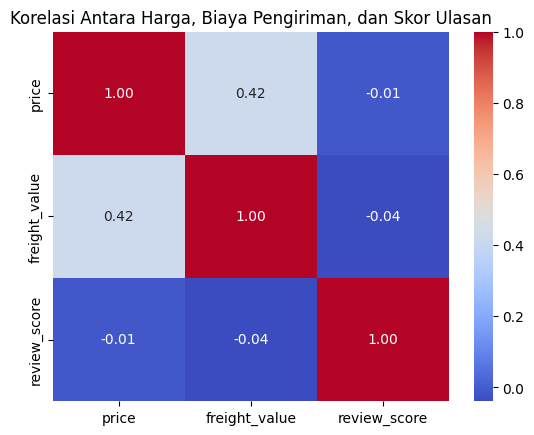

In [95]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi Antara Harga, Biaya Pengiriman, dan Skor Ulasan')
plt.show()

In [96]:
# Rata-rata skor ulasan per kategori produk
category_scores = orders_products_df.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False)
print(category_scores)

product_category_name_english
cds_dvds_musicals          4.666667
flowers                    4.538462
books_general_interest     4.462451
costruction_tools_tools    4.425532
books_technical            4.421260
                             ...   
diapers_and_hygiene        3.740741
fashio_female_clothing     3.736842
fashion_male_clothing      3.727273
office_furniture           3.626889
security_and_services      2.500000
Name: review_score, Length: 71, dtype: float64


In [97]:
# Rata-rata skor ulasan per metode pembayaran
payment_scores = orders_products_df.groupby('payment_type')['review_score'].mean()
print(payment_scores)

payment_type
boleto         4.110069
credit_card    4.106600
debit_card     4.183288
voucher        4.080326
Name: review_score, dtype: float64


In [98]:
# Hitung waktu pengiriman (dalam hari)
orders_products_df['delivery_days'] = (
    orders_products_df['order_delivered_customer_date'] -
    orders_products_df['order_purchase_timestamp']
).dt.days

In [99]:
# Korelasi waktu pengiriman dengan skor ulasan
print(orders_products_df[['delivery_days', 'review_score']].corr())

               delivery_days  review_score
delivery_days       1.000000     -0.275501
review_score       -0.275501      1.000000


In [100]:
orders_products_df['order_purchase_timestamp'] = pd.to_datetime(orders_products_df['order_purchase_timestamp'])

In [101]:
orders_products_df['year'] = orders_products_df['order_purchase_timestamp'].dt.year
orders_products_df['month'] = orders_products_df['order_purchase_timestamp'].dt.month


In [102]:
orders_products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96485 entries, 0 to 97915
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96485 non-null  object        
 1   customer_id                    96485 non-null  object        
 2   order_status                   96485 non-null  object        
 3   order_purchase_timestamp       96485 non-null  datetime64[ns]
 4   order_approved_at              96485 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96485 non-null  datetime64[ns]
 6   order_delivered_customer_date  96485 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96485 non-null  datetime64[ns]
 8   qty_order                      96485 non-null  float64       
 9   product_id                     96485 non-null  object        
 10  seller_id                      96485 non-null  object        
 11  shipping_limit_date 

In [103]:
monthly_sales = orders_products_df.groupby(['year', 'month'])['price'].agg(['sum', 'count']).reset_index()
monthly_sales.rename(columns={'sum': 'total_sales', 'count': 'number_of_orders'}, inplace=True)
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))

In [104]:
print(monthly_sales)

    year  month  total_sales  number_of_orders       date
0   2016      9        92.40                 2 2016-09-01
1   2016     10     44734.23               301 2016-10-01
2   2016     12        10.90                 1 2016-12-01
3   2017      1    103279.70               767 2017-01-01
4   2017      2    219501.06              1670 2017-02-01
5   2017      3    335709.39              2568 2017-03-01
6   2017      4    322468.68              2310 2017-04-01
7   2017      5    448715.28              3541 2017-05-01
8   2017      6    398329.36              3136 2017-06-01
9   2017      7    445276.49              3882 2017-07-01
10  2017      8    514779.81              4196 2017-08-01
11  2017      9    550989.38              4147 2017-09-01
12  2017     10    577382.01              4473 2017-10-01
13  2017     11    887314.29              7279 2017-11-01
14  2017     12    664974.88              5433 2017-12-01
15  2018      1    838108.15              6974 2018-01-01
16  2018      

In [105]:
monthly_sales['growth_rate'] = (monthly_sales['total_sales'].pct_change() * 100).round(2)
print(monthly_sales[['month', 'year', 'total_sales', 'growth_rate']])

    month  year  total_sales  growth_rate
0       9  2016        92.40          NaN
1      10  2016     44734.23     48313.67
2      12  2016        10.90       -99.98
3       1  2017    103279.70    947420.18
4       2  2017    219501.06       112.53
5       3  2017    335709.39        52.94
6       4  2017    322468.68        -3.94
7       5  2017    448715.28        39.15
8       6  2017    398329.36       -11.23
9       7  2017    445276.49        11.79
10      8  2017    514779.81        15.61
11      9  2017    550989.38         7.03
12     10  2017    577382.01         4.79
13     11  2017    887314.29        53.68
14     12  2017    664974.88       -25.06
15      1  2018    838108.15        26.04
16      2  2018    752832.81       -10.17
17      3  2018    875816.81        16.34
18      4  2018    898881.89         2.63
19      5  2018    883159.65        -1.75
20      6  2018    786443.17       -10.95
21      7  2018    802102.96         1.99
22      8  2018    783389.07      

In [106]:
peak_month = monthly_sales.loc[monthly_sales['total_sales'].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales['total_sales'].idxmin()]

print(f"Puncak Penjualan: {peak_month['month']}-{peak_month['year']} ($ {peak_month['total_sales']:.2f})")
print(f"Lembah Penjualan: {lowest_month['month']}-{lowest_month['year']} ($ {lowest_month['total_sales']:.2f})")

Puncak Penjualan: 4-2018 ($ 898881.89)
Lembah Penjualan: 12-2016 ($ 10.90)


## Visualization & Explanatory Analysis

### Pertanyaan 1 : Metode pembayaran apa yang paling sering digunakan oleh pelanggan?

In [107]:
orders_products_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,qty_order,product_id,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,month_year,price_range,freight_range,delivery_days,year,month
52093,88ac33fac1d5d735fecc0f5fca69b0b0,081d97688ce99393dda013bdd97d15de,delivered,2017-11-24 17:22:24,2017-11-25 03:52:00,2017-11-29 15:03:51,2017-12-06 14:52:28,2017-12-14,1.0,1b11571a0535a643bb18db34b84b7334,...,21.0,15.0,25.0,cool_stuff,2017-11,50-100,<20,11,2017,11
56353,94334c434972d5f591d2e72330935d25,7646338721482cc1c3429c76ae261c94,delivered,2018-06-24 17:15:56,2018-06-24 17:34:13,2018-06-28 12:25:00,2018-07-03 03:52:32,2018-07-31,1.0,c6c3f359bed2ca70506331f0a05d9c06,...,16.0,16.0,16.0,auto,2018-06,<50,<20,8,2018,6
16127,2a7f6f7d1d01dcffbddff5e6e3ad791f,fb9bfdd81da81e42e604a4be97092130,delivered,2018-03-18 14:44:29,2018-03-18 15:07:59,2018-03-20 19:25:32,2018-04-09 18:03:17,2018-04-17,1.0,2ea654ee9e83b7622ce3ac79ce772970,...,65.0,6.0,48.0,art,2018-03,50-100,20-50,22,2018,3
9782,199143704f839c9a7e8eb0ce7b52fcdf,8699daec121578c9a9acfdb360ffe2e1,delivered,2018-04-18 15:36:07,2018-04-19 02:51:13,2018-04-25 16:07:00,2018-04-30 15:51:54,2018-05-11,1.0,2647221a6a477afe2d0268b378f1fdcd,...,40.0,4.0,30.0,bed_bath_table,2018-04,<50,<20,12,2018,4
74793,c396df58ede55fc38761c0382b3bc791,2c5231dc7965bc16ec4e2b8dec37cf72,delivered,2017-12-14 09:05:11,2017-12-15 02:17:13,2017-12-15 18:47:26,2018-01-06 18:59:43,2018-01-12,2.0,389d119b48cf3043d311335e499d9c6b,...,37.0,22.0,40.0,garden_tools,2017-12,50-100,20-50,23,2017,12


In [108]:
orders_products_df.payment_type.value_counts()

,count
payment_type,
credit_card,73227
boleto,19197
voucher,2577
debit_card,1484


In [109]:
payment_summary_df = orders_products_df['payment_type'].value_counts().reset_index()
payment_summary_df.columns = ['payment_type', 'quantity']
print(payment_summary_df)

  payment_type  quantity
0  credit_card     73227
1       boleto     19197
2      voucher      2577
3   debit_card      1484


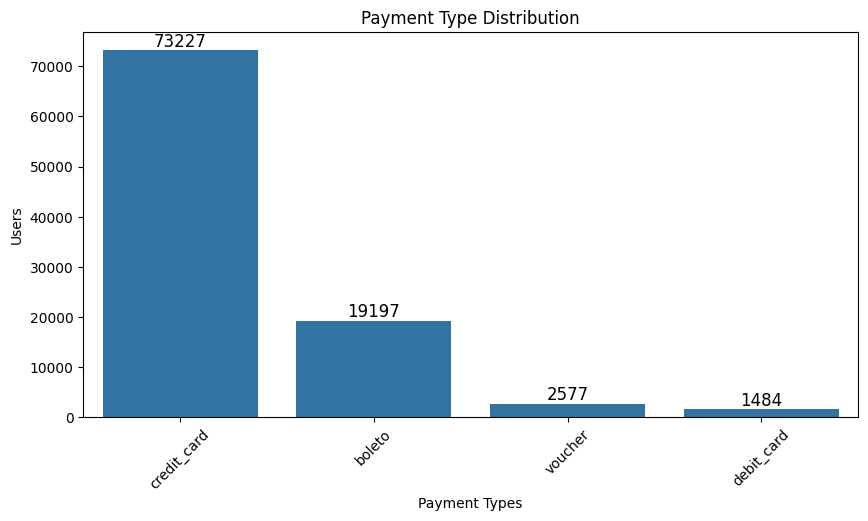

In [110]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=payment_summary_df, x='payment_type', y='quantity')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black')

plt.xlabel('Payment Types')
plt.ylabel('Users')
plt.title('Payment Type Distribution')
plt.xticks(rotation=45)

plt.show()

Berdasarkan grafik yang di tampilkan, dapat dilihat bahwa metode pembayaran yang paling banyak digunakan adalah menggunakan credit card dan terendah menggunakan debit card

### Pertanyaan 2: Bagaimana Tren Penjualan tiap bulannya dan evolusinya seiring waktu?


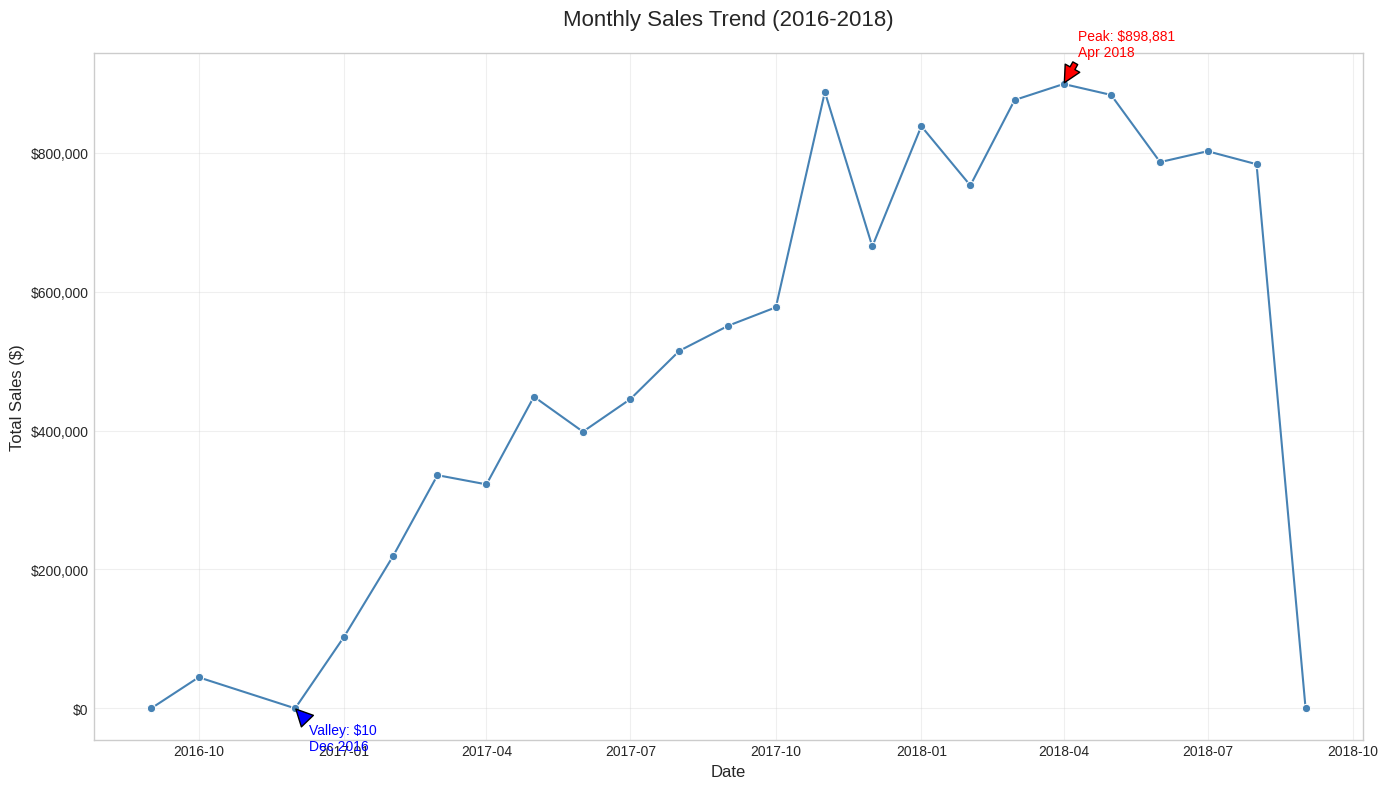

In [111]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(14, 8))

sns.lineplot(x='date', y='total_sales', data=monthly_sales, marker='o', linestyle='-', color='steelblue', ax=ax)

ax.set_title('Monthly Sales Trend (2016-2018)', fontsize=16, pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x):,}'))

ax.grid(True, alpha=0.3)

peak = monthly_sales.loc[monthly_sales['total_sales'].idxmax()]
valley = monthly_sales.loc[monthly_sales['total_sales'].idxmin()]

ax.annotate(f'Peak: ${int(peak["total_sales"]):,}\n{peak["date"].strftime("%b %Y")}',
            xy=(date2num(peak['date']), peak['total_sales']),
            xytext=(10, 20), textcoords='offset points',
            arrowprops=dict(facecolor='red', shrink=0.05),
            color='red', fontsize=10)

ax.annotate(f'Valley: ${int(valley["total_sales"]):,}\n{valley["date"].strftime("%b %Y")}',
            xy=(date2num(valley['date']), valley['total_sales']),
            xytext=(10, -30), textcoords='offset points',
            arrowprops=dict(facecolor='blue', shrink=0.05),
            color='blue', fontsize=10)

plt.tight_layout()
plt.show()



Grafik garis menunjukkan tren penjualan bulanan dari 2016 hingga 2018. Dapat diamati bahwa penjualan secara umum mengalami peningkatan selama periode tersebut, yang menunjukkan pertumbuhan bisnis. Tren naik ini mengindikasikan penetrasi pasar yang berhasil dan potensi strategi pemasaran yang efektif.
Pola Musiman
Penjualan tertinggi terjadi pada April 2018 dan penjualan terendah terjadi pada Desember 2012


### Pertanyaan 3: Bagaimana hubungan antara harga produk, biaya pengiriman dan skor ulasan pelanggan?


(1.0, 5.0)

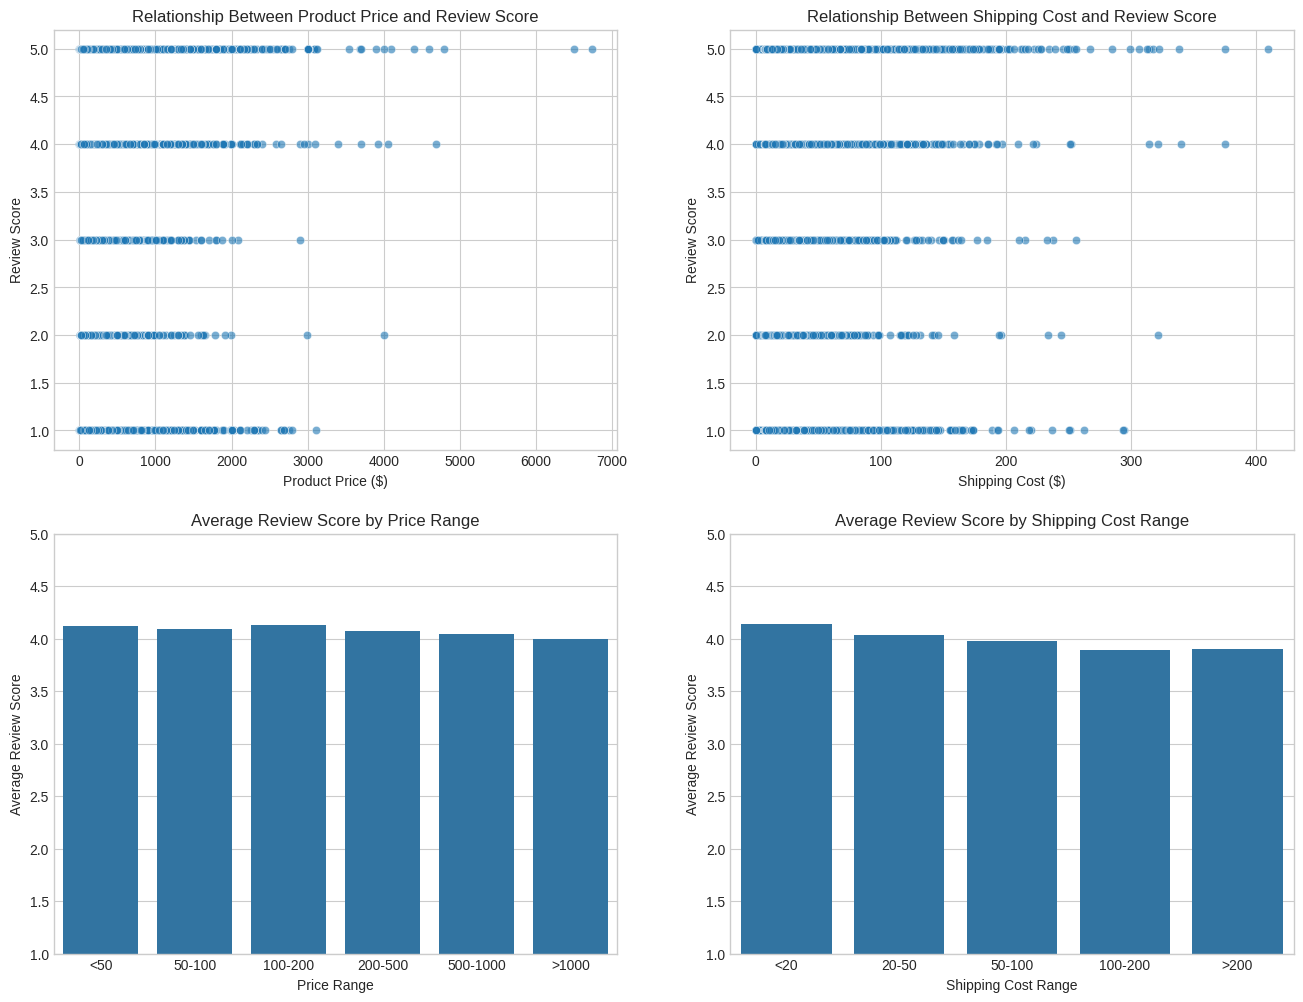

In [112]:
# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Create figure with subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

# Scatter plot: Price vs Review Score
sns.scatterplot(data=orders_products_df, x='price', y='review_score', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Relationship Between Product Price and Review Score')
axes[0, 0].set_xlabel('Product Price ($)')
axes[0, 0].set_ylabel('Review Score')

# Scatter plot: Freight Value vs Review Score
sns.scatterplot(data=orders_products_df, x='freight_value', y='review_score', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Relationship Between Shipping Cost and Review Score')
axes[0, 1].set_xlabel('Shipping Cost ($)')
axes[0, 1].set_ylabel('Review Score')

# Bar plot: Average Review Score by Price Range
sns.barplot(data=price_review, x='price_range', y='mean', ax=axes[1, 0])
axes[1, 0].set_title('Average Review Score by Price Range')
axes[1, 0].set_xlabel('Price Range')
axes[1, 0].set_ylabel('Average Review Score')
axes[1, 0].set_ylim(1, 5)

# Bar plot: Average Review Score by Shipping Cost Range
sns.barplot(data=freight_review, x='freight_range', y='mean', ax=axes[1, 1])
axes[1, 1].set_title('Average Review Score by Shipping Cost Range')
axes[1, 1].set_xlabel('Shipping Cost Range')
axes[1, 1].set_ylabel('Average Review Score')
axes[1, 1].set_ylim(1, 5)



- Hubungan Harga Produk dengan Skor Ulasan
Korelasi Lemah: Koefisien korelasi sebesar -0.01 menunjukkan hampir tidak ada hubungan linear antara harga produk dan skor ulasan pelanggan.
- Koefisien korelasi sebesar -0.04 menunjukkan adanya hubungan negatif yang sangat lemah antara biaya pengiriman dan skor ulasan.
- Produk di semua rentang harga (<50, 50-100, 100-200, 200-500, 500-1000, >1000) mendapatkan skor ulasan rata-rata yang serupa, berkisar antara 4.0 hingga 4.2.
- Terdapat tren penurunan skor ulasan yang sangat kecil seiring peningkatan biaya pengiriman. Skor ulasan turun dari sekitar 4.1 untuk rentang <20 menjadi 3.9 untuk rentang >200.

### Pertanyaan 4: Analisa RFM

In [113]:
# Calculate RFM metrics
now = all_df['order_purchase_timestamp'].max()
rfm_df = all_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (now - x.max()).days,  # Recency
    'order_id': 'nunique',                                       # Frequency
    'payment_value': 'sum'                                       # Monetary
}).reset_index()

In [114]:
# Create numeric ID for customers
rfm_df['numeric_id'] = pd.factorize(rfm_df['customer_id'])[0] + 1

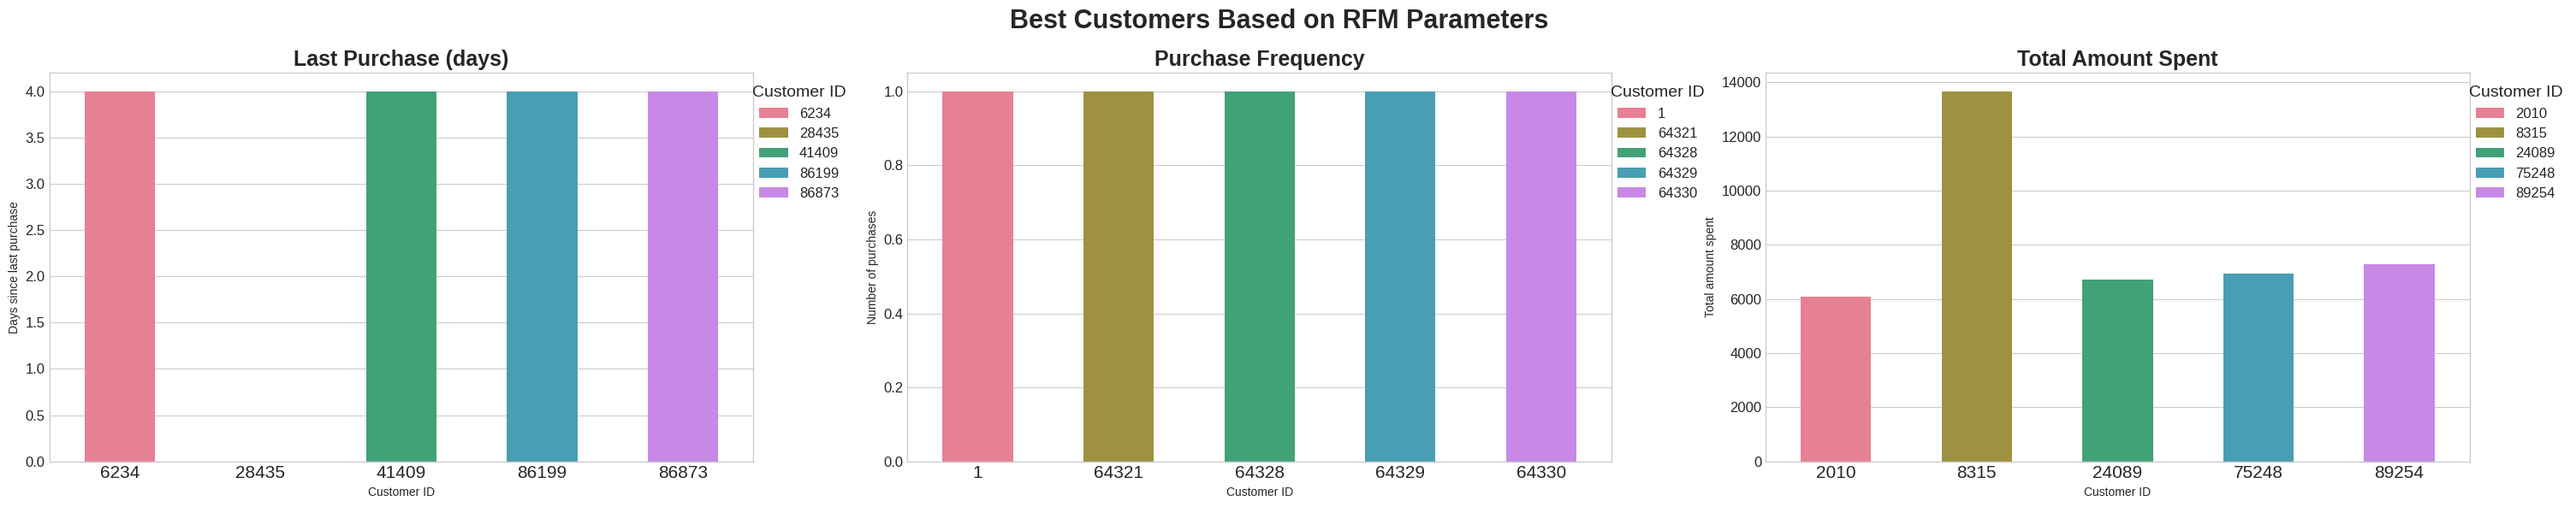

In [115]:
# Create figure with subplots
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))
colors = sns.color_palette("husl", 5)

# Bar plot for Recency (Last Purchase)
sns.barplot(
    y="order_purchase_timestamp",
    x='numeric_id',
    data=rfm_df.sort_values(by='order_purchase_timestamp', ascending=True).head(5),
    hue='numeric_id',
    palette=colors,
    ax=ax[0],
    dodge=False,
    width=0.5
)
ax[0].set_ylabel('Days since last purchase')
ax[0].set_xlabel('Customer ID')
ax[0].set_title('Last Purchase (days)', loc='center', fontsize=18, fontweight='bold')
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=12)
ax[0].legend(title='Customer ID', fontsize=12, title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1))

# Bar plot for Frequency (Number of Purchases)
sns.barplot(
    y='order_id',
    x='numeric_id',
    data=rfm_df.sort_values(by='order_id', ascending=False).head(5),
    hue='numeric_id',
    palette=colors,
    ax=ax[1],
    dodge=False,
    width=0.5
)
ax[1].set_ylabel('Number of purchases')
ax[1].set_xlabel('Customer ID')
ax[1].set_title('Purchase Frequency', loc='center', fontsize=18, fontweight='bold')
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].legend(title='Customer ID', fontsize=12, title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1))

# Bar plot for Monetary (Total Money Spent)
sns.barplot(
    y='payment_value',
    x='numeric_id',
    data=rfm_df.sort_values(by='payment_value', ascending=False).head(5),
    hue='numeric_id',
    palette=colors,
    ax=ax[2],
    dodge=False,
    width=0.5
)
ax[2].set_ylabel('Total amount spent')
ax[2].set_xlabel('Customer ID')
ax[2].set_title('Total Amount Spent', loc='center', fontsize=18, fontweight='bold')
ax[2].tick_params(axis='x', labelsize=15)
ax[2].tick_params(axis='y', labelsize=12)
ax[2].legend(title='Customer ID', fontsize=12, title_fontsize=14, loc='upper right', bbox_to_anchor=(1.15, 1))

plt.suptitle('Best Customers Based on RFM Parameters', fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()

Berdasarkan visualisasi data di atas, dapat diambil kesimpulan sebagai berikut:
Recency (Keterbelakangan Pembelian): Beberapa pelanggan telah melakukan transaksi dalam rentang 0 hingga 4 hari terakhir, dengan transaksi paling baru dilakukan oleh pelanggan dengan ID 28435.
Frequency (Frekuensi Pembelian): Sebagian besar pelanggan hanya melakukan pembelian sekali dalam beberapa bulan terakhir, yang menunjukkan pola pembelian yang relatif jarang.
Monetary (Jumlah Uang yang Dihabiskan): Jumlah uang yang dihabiskan oleh pelanggan beragam. Pelanggan dengan ID 8315 adalah yang paling banyak menghabiskan uang.
Dari ketiga parameter RFM tersebut, dapat diidentifikasi pelanggan terbaik yang paling aktif dan menghabiskan uang paling banyak dalam periode yang dianalisis.

Pertanyaan 5: Provinsi mana yang memiliki total penjualan tertinggi dan terendah?

In [116]:
# Menghitung total penjualan per provinsi (sudah ada di kode asli)
state_sales = all_df.groupby('customer_state')['price'].sum().reset_index()
state_sales.rename(columns={'price': 'total_sales'}, inplace=True)
state_sales = state_sales.sort_values('total_sales', ascending=False)

<ipython-input-117-c685351f8b52>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_sales', y='customer_state', data=state_sales, palette='rocket', orient='h')


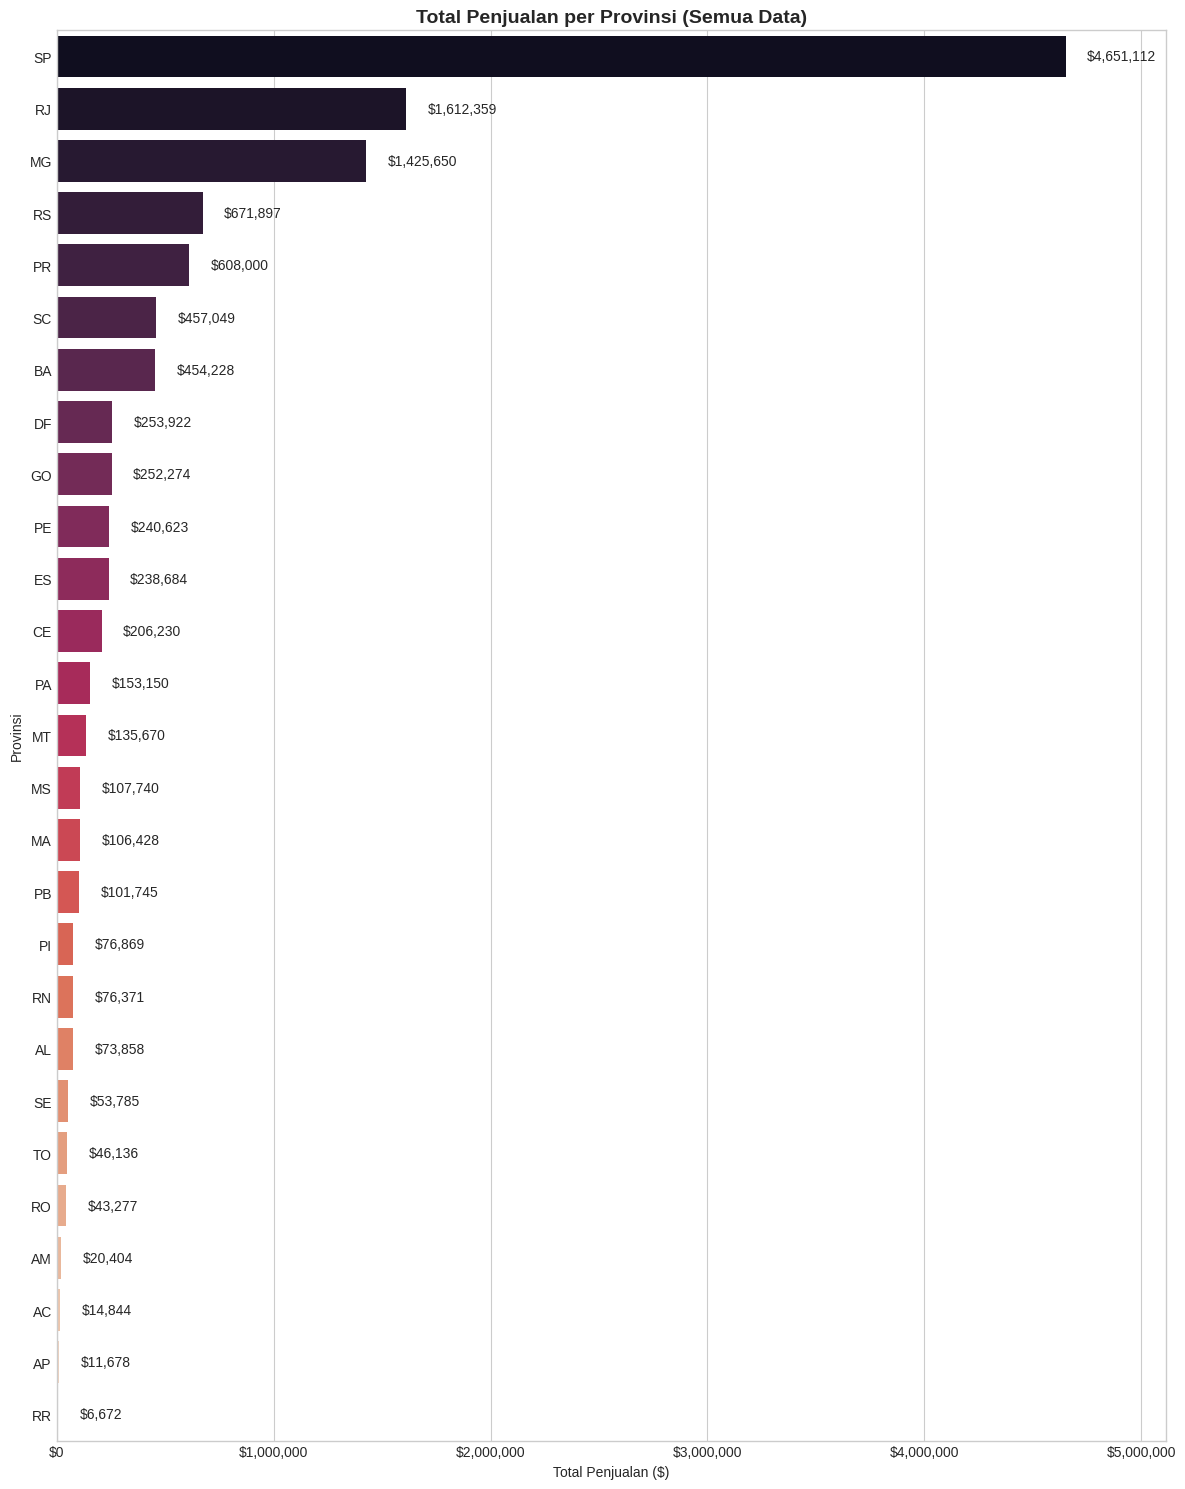

In [117]:
# Membuat figure dengan ukuran yang lebih panjang untuk menampung semua provinsi
plt.figure(figsize=(12, 15))

# Plot horizontal bar chart untuk semua provinsi
sns.barplot(x='total_sales', y='customer_state', data=state_sales, palette='rocket', orient='h')

# Menambahkan judul dan label
plt.title('Total Penjualan per Provinsi (Semua Data)', fontsize=14, fontweight='bold')
plt.xlabel('Total Penjualan ($)')
plt.ylabel('Provinsi')

# Format x-axis sebagai mata uang
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x):,}'))

# Menambahkan nilai pada ujung batang
for p in plt.gca().patches:
    width = p.get_width()
    plt.gca().text(width + 100000,  # Posisi x (sedikit di sebelah kanan batang)
                  p.get_y() + p.get_height()/2,  # Posisi y (tengah batang)
                  f'${int(width):,}',
                  ha='left',
                  va='center')

# Mengatur batas x agar label tidak terpotong
plt.xlim(0, max(state_sales['total_sales']) * 1.1)

plt.tight_layout()
plt.show()

Berdasarkan grafik total penjualan per provinsi, dapat disimpulkan bahwa provinsi dengan penjualan tertinggi adalah São Paulo (SP), dengan jarak yang signifikan dibandingkan provinsi lainnya. Sebaliknya, provinsi dengan penjualan terendah adalah Roraima (RR), Amapá (AP), Acre (AC), dan Amazonas (AM). Hal ini menunjukkan distribusi penjualan yang tidak merata, di mana provinsi yang lebih besar atau lebih maju cenderung memiliki volume penjualan yang jauh lebih tinggi.

## Conclusion

1. Metode pembayaran apa yang paling sering digunakan oleh pelanggan?
Berdasarkan analisis distribusi metode pembayaran yang ditampilkan pada grafik di atas, dapat disimpulkan sebagai berikut:
- Metode Pembayaran Paling Populer: Credit card adalah metode pembayaran yang paling banyak digunakan dengan jumlah pengguna sebanyak 73.227 orang. Hal ini menunjukkan preferensi yang sangat tinggi dari pelanggan terhadap pembayaran menggunakan kartu kredit.
- Metode Pembayaran Alternatif: Boleto sebagai metode pembayaran non-kartu juga memiliki pengguna yang cukup banyak, yaitu 19.197 orang, menempatinya pada posisi kedua dalam preferensi pelanggan.
- Metode Pembayaran Kurang Populer: Voucher dan debit card menempati posisi terbawah dalam preferensi metode pembayaran. Voucher digunakan oleh 2.577 orang, sedangkan debit card hanya digunakan oleh 1.484 orang, yang menunjukkan adanya peluang untuk meningkatkan adopsi metode pembayaran ini melalui strategi pemasaran yang lebih efektif.

2. Bagaimana Tren Penjualan tiap bulannya dan evolusinya seiring waktu?
- Grafik menunjukkan adanya peningkatan penjualan secara keseluruhan selama periode 2016-2018. Hal ini mengindikasikan pertumbuhan bisnis yang positif dan efektivitas strategi pemasaran yang diterapkan.
- Puncak penjualan tertinggi terjadi pada April 2018 dan Titik terendah penjualan terjadi pada Desember 2016
- Fluktuasi bulanan yang signifikan menunjukkan adanya variasi permintaan setiap bulannya

3. Bagaimana hubungan antara harga produk, biaya pengiriman dan skor ulasan pelanggan?
- Pelanggan memberikan penilaian yang serupa terhadap produk tidak peduli berapa harga produknya. Hal ini menunjukkan bahwa kualitas produk lebih berpengaruh terhadap skor ulasan dibandingkan harga. terdapat cenderung penurunan skor ulasan seiring peningkatan biaya pengiriman. Ini mengindikasikan bahwa biaya pengiriman yang tinggi mungkin sedikit memengaruhi kepuasan pelanggan.

4. Bagaimana mengelompokkan pelanggan berdasarkan perilaku pembelian mereka (Recency, Frequency, Monetary)?
- Recency (Keterbelakangan Pembelian) :
Beberapa pelanggan telah melakukan transaksi dalam rentang 0 hingga 4 hari terakhir. Pelanggan dengan ID 28435 adalah yang terbaru melakukan transaksi, menunjukkan tingkat aktivitas yang tinggi.

- Frequency (Frekuensi Pembelian) : Sebagian besar pelanggan hanya melakukan pembelian sekali dalam periode analisis. Hal ini menunjukkan pola pembelian yang relatif jarang, dengan sedikit pelanggan yang menunjukkan loyalitas tinggi atau frekuensi pembelian yang tinggi.

- Monetary (Jumlah Uang yang Dihabiskan): Jumlah uang yang dihabiskan oleh pelanggan beragam. Pelanggan dengan ID 8315 adalah yang paling banyak menghabiskan uang, menunjukkan tingkat keterlibatan finansial yang signifikan.
Pelanggan dengan ID 2010, 24089, 75248, dan 89254 juga menunjukkan kontribusi moneternya yang cukup tinggi, meskipun tidak sebanyak pelanggan ID 8315.

- Berdasarkan ketiga parameter RFM, pelanggan dengan ID 8315 teridentifikasi sebagai pelanggan terbaik. Pelanggan ini menunjukkan:Tingkat aktivitas yang tinggi (Recency rendah) Frekuensi pembelian yang konsisten Total pengeluaran yang tinggi

5. Provinsi mana yang memiliki total penjualan tertinggi dan terendah?
-Provinsi São Paulo (SP) menunjukkan penjualan tertinggi dengan total Rp4,651,112, jauh meninggalkan provinsi lainnya. Provinsi seperti Roraima (RR), Amapá (AP), Acre (AC), dan Amazonas (AM) menunjuTerdapat ketimpangan yang signifikan dalam distribusi penjualan antar provinsi. Provinsi-provinsi besar dan maju mendominasi sebagian besar penjualan, sementara provinsi-provinsi kecil atau terpencil memiliki kontribusi yang sangat minim.